# **Análisis estadístico y depuración del código**

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import numpy as np

In [9]:
da_SGC_50 = pd.read_csv('../datos/datos originales/SGC-50KM.csv')
da_SGC_260 = pd.read_csv('../datos/datos originales/SGC-260KM.csv')
da_USGS_50 = pd.read_csv('../datos/datos originales/USGS-50KM.csv')
da_USGC_260 = pd.read_csv('../datos/datos originales/USGS-260KM.csv')

In [15]:
import pandas as pd
import os

# 1. Rutas de los archivos SGC
archivos_sgc = [
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-50KM.csv",
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-260KM.csv"
]

# 2. Diccionario para renombrar columnas del SGC
columnas_map_sgc = {
    'agency': 'agencia',
    'place': 'lugar',
    'local_time': 'hora',
    'latitude': 'latitud',
    'longitude': 'longitud',
    'magnitude': 'magnitud',
    'mag_type': 'tipo_magnitud',
    'depth': 'profundidad'
}

orden_columnas = [
    'agencia', 'lugar', 'hora', 'latitud', 'longitud', 
    'magnitud', 'tipo_magnitud', 'profundidad'
]

dataframes_procesados = []

# Procesar cada archivo del SGC
for archivo in archivos_sgc:
    try:
        df = pd.read_csv(archivo)
        
        # Evitar columnas duplicadas
        df = df.loc[:, ~df.columns.duplicated()]
        
        # Renombrar y filtrar
        df.rename(columns=columnas_map_sgc, inplace=True)
        columnas_finales = [col for col in orden_columnas if col in df.columns]
        df_transformado = df[columnas_finales]
        
        # Guardar archivo con sufijo _n
        ruta_base, extension = os.path.splitext(archivo)
        nuevo_archivo = f"{ruta_base}_n{extension}"
        df_transformado.to_csv(nuevo_archivo, index=False)
        print(f"[ÉXITO] Archivo transformado y guardado: {os.path.basename(nuevo_archivo)}")
        
        # Guardar en la lista para el análisis global
        dataframes_procesados.append(df_transformado)

    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {archivo}. Verifica la ruta.")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema con {os.path.basename(archivo)}: {e}")

# --- ANÁLISIS ESTADÍSTICO CONJUNTO ---
if len(dataframes_procesados) > 0:
    print("\n" + "="*70)
    print("ANÁLISIS ESTADÍSTICO GLOBAL (SGC 50KM + 260KM COMBINADOS)")
    print("="*70)
    
    # Unir todos los DataFrames cargados exitosamente
    df_total = pd.concat(dataframes_procesados, ignore_index=True)
    
    print("\n--- REVISIÓN DE VALORES NULOS (TOTAL) ---")
    print(df_total.isnull().sum())
    
    print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---")
    print(df_total.describe(include='all'))
else:
    print("\nNo se pudieron cargar los archivos para el análisis.")

[ÉXITO] Archivo transformado y guardado: SGC-50KM_n.csv
[ÉXITO] Archivo transformado y guardado: SGC-260KM_n.csv

ANÁLISIS ESTADÍSTICO GLOBAL (SGC 50KM + 260KM COMBINADOS)

--- REVISIÓN DE VALORES NULOS (TOTAL) ---
agencia          0
lugar            0
hora             0
latitud          0
longitud         0
magnitud         0
tipo_magnitud    0
profundidad      0
dtype: int64

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---
       agencia                     lugar                       hora  \
count    70161                     70161                      70161   
unique       4                       457                      67756   
top        SGC  Mesetas - Meta, Colombia  2026-06-10T19:45:56+00:00   
freq     70144                      5221                          4   
mean       NaN                       NaN                        NaN   
std        NaN                       NaN                        NaN   
min        NaN                       NaN                        NaN   
25% 

In [16]:
import pandas as pd
import os

# 1. Rutas de los archivos USGS
archivos_usgs = [
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-50KM.csv",
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-260KM.csv"
]

# 2. Diccionario para renombrar columnas del USGS
columnas_map_usgs = {
    'net': 'agencia',
    'place': 'lugar',
    'time': 'hora',
    'latitude': 'latitud',
    'longitude': 'longitud',
    'mag': 'magnitud',
    'magType': 'tipo_magnitud',
    'depth': 'profundidad'
}

orden_columnas = [
    'agencia', 'lugar', 'hora', 'latitud', 'longitud', 
    'magnitud', 'tipo_magnitud', 'profundidad'
]

dataframes_procesados = []

# Procesar cada archivo del USGS
for archivo in archivos_usgs:
    try:
        df = pd.read_csv(archivo)
        
        # Evitar columnas duplicadas
        df = df.loc[:, ~df.columns.duplicated()]
        
        # Renombrar y filtrar
        df.rename(columns=columnas_map_usgs, inplace=True)
        columnas_finales = [col for col in orden_columnas if col in df.columns]
        df_transformado = df[columnas_finales]
        
        # Guardar archivo con sufijo _n
        ruta_base, extension = os.path.splitext(archivo)
        nuevo_archivo = f"{ruta_base}_n{extension}"
        df_transformado.to_csv(nuevo_archivo, index=False)
        print(f"[ÉXITO] Archivo transformado y guardado: {os.path.basename(nuevo_archivo)}")
        
        # Guardar en la lista para el análisis global
        dataframes_procesados.append(df_transformado)

    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {archivo}. Verifica la ruta.")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema con {os.path.basename(archivo)}: {e}")

# --- ANÁLISIS ESTADÍSTICO CONJUNTO ---
if len(dataframes_procesados) > 0:
    print("\n" + "="*70)
    print("ANÁLISIS ESTADÍSTICO GLOBAL (USGS 50KM + 260KM COMBINADOS)")
    print("="*70)
    
    # Unir todos los DataFrames cargados exitosamente
    df_total = pd.concat(dataframes_procesados, ignore_index=True)
    
    print("\n--- REVISIÓN DE VALORES NULOS (TOTAL) ---")
    print(df_total.isnull().sum())
    
    print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---")
    print(df_total.describe(include='all'))
else:
    print("\nNo se pudieron cargar los archivos para el análisis.")

[ÉXITO] Archivo transformado y guardado: USGS-50KM_n.csv
[ÉXITO] Archivo transformado y guardado: USGS-260KM_n.csv

ANÁLISIS ESTADÍSTICO GLOBAL (USGS 50KM + 260KM COMBINADOS)

--- REVISIÓN DE VALORES NULOS (TOTAL) ---
agencia           0
lugar             0
hora              0
latitud           0
longitud          0
magnitud          0
tipo_magnitud    12
profundidad       0
dtype: int64

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---
       agencia     lugar                      hora     latitud    longitud  \
count      843       843                       843  843.000000  843.000000   
unique       2       768                       823         NaN         NaN   
top         us  Colombia  2025-12-21T14:05:26.416Z         NaN         NaN   
freq       828        16                         2         NaN         NaN   
mean       NaN       NaN                       NaN    3.916390  -75.887981   
std        NaN       NaN                       NaN    0.769623    0.941887   
min        NaN 


PROCESANDO UNIFICACIÓN: Radio 50 KM
Filas iniciales: 2400 | Filas tras eliminar nulos: 2400
[ÉXITO] Archivo depurado guardado en:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_50KM_Depurados.csv

--- ESTADÍSTICAS DE MAGNITUD (Radio 50 KM) ---
count    2400.000000
mean        1.842996
std         0.628043
min         0.700000
25%         1.400000
50%         1.700000
75%         2.100000
max         5.500000
Name: magnitud, dtype: float64

Abriendo ventana de gráficos para Radio 50 KM...


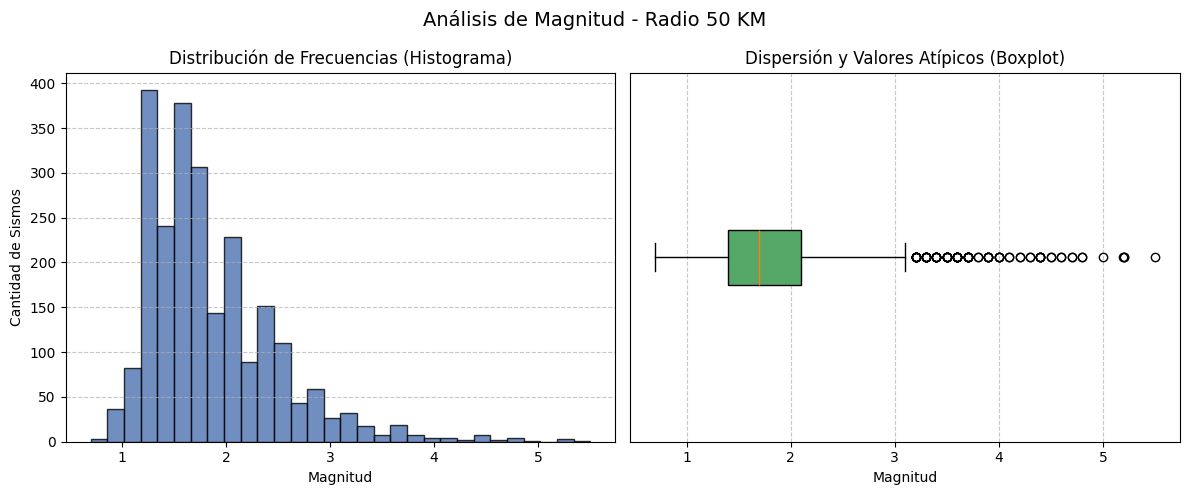


PROCESANDO UNIFICACIÓN: Radio 260 KM
Filas iniciales: 68604 | Filas tras eliminar nulos: 68592
[ÉXITO] Archivo depurado guardado en:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_260KM_Depurados.csv

--- ESTADÍSTICAS DE MAGNITUD (Radio 260 KM) ---
count    68592.000000
mean         1.701604
std          0.686206
min         -0.100000
25%          1.200000
50%          1.600000
75%          2.000000
max          7.400000
Name: magnitud, dtype: float64

Abriendo ventana de gráficos para Radio 260 KM...


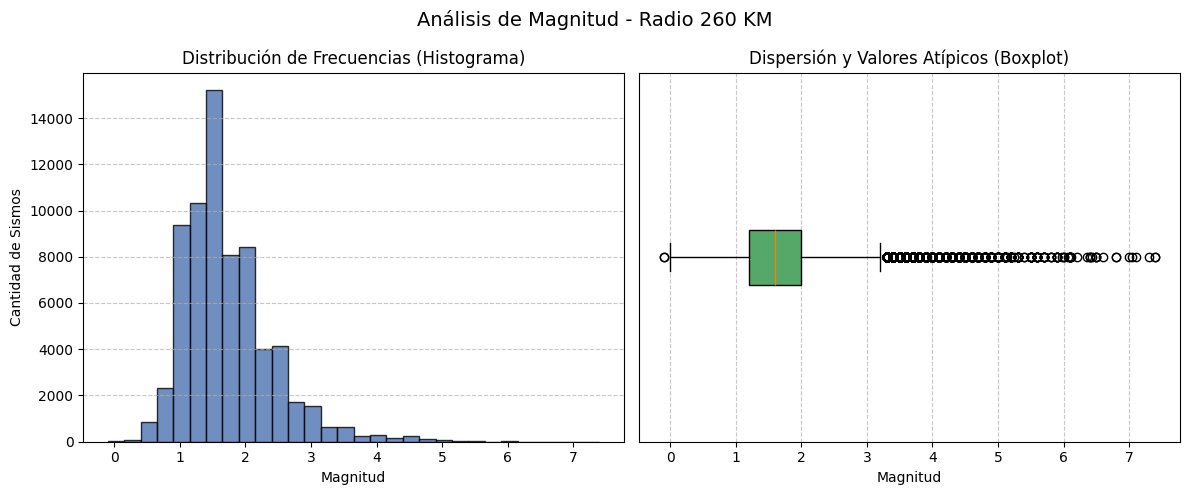

In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Definir rutas de entrada
ruta_sgc_50 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-50KM_n.csv"
ruta_usgs_50 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-50KM_n.csv"

ruta_sgc_260 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-260KM_n.csv"
ruta_usgs_260 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-260KM_n.csv"

# 2. Definir ruta de salida y asegurar que el directorio exista
ruta_salida_dir = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"
os.makedirs(ruta_salida_dir, exist_ok=True)

def procesar_unificacion_y_graficos(archivo_sgc, archivo_usgs, nombre_salida, titulo):
    print(f"\n" + "="*60)
    print(f"PROCESANDO UNIFICACIÓN: {titulo}")
    print("="*60)
    
    try:
        # Cargar ambos archivos transformados
        df_sgc = pd.read_csv(archivo_sgc)
        df_usgs = pd.read_csv(archivo_usgs)
        
        # Unificar (concatenar) los dos DataFrames
        df_unificado = pd.concat([df_sgc, df_usgs], ignore_index=True)
        total_inicial = len(df_unificado)
        
        # Eliminar filas con cualquier valor nulo
        df_unificado.dropna(inplace=True)
        total_final = len(df_unificado)
        print(f"Filas iniciales: {total_inicial} | Filas tras eliminar nulos: {total_final}")
        
        # Guardar en la nueva ruta
        ruta_final = os.path.join(ruta_salida_dir, nombre_salida)
        df_unificado.to_csv(ruta_final, index=False)
        print(f"[ÉXITO] Archivo depurado guardado en:\n{ruta_final}")
        
        # --- ESTADÍSTICA DESCRIPTIVA DE LA MAGNITUD ---
        print(f"\n--- ESTADÍSTICAS DE MAGNITUD ({titulo}) ---")
        print(df_unificado['magnitud'].describe())
        
        # --- GRAFICAR DISTRIBUCIÓN ---
        # Crear una figura con dos subgráficos (Histograma y Boxplot)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Análisis de Magnitud - {titulo}', fontsize=14)
        
        # Histograma
        axes[0].hist(df_unificado['magnitud'], bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
        axes[0].set_title('Distribución de Frecuencias (Histograma)')
        axes[0].set_xlabel('Magnitud')
        axes[0].set_ylabel('Cantidad de Sismos')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Boxplot (Diagrama de caja)
        axes[1].boxplot(df_unificado['magnitud'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#55A868', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos (Boxplot)')
        axes[1].set_xlabel('Magnitud')
        axes[1].set_yticks([]) # Ocultar el número 1 del eje Y
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        
        # Mostrar el gráfico en pantalla
        print(f"\nAbriendo ventana de gráficos para {titulo}...")
        plt.show()
        
    except FileNotFoundError as e:
        print(f"[ERROR] No se encontró uno de los archivos para {titulo}. Detalles: {e}")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema inesperado en {titulo}: {e}")

# 3. Ejecutar el proceso para la base de 50 KM
procesar_unificacion_y_graficos(
    ruta_sgc_50, 
    ruta_usgs_50, 
    "Sismos_50KM_Depurados.csv", 
    "Radio 50 KM"
)

# 4. Ejecutar el proceso para la base de 260 KM
procesar_unificacion_y_graficos(
    ruta_sgc_260, 
    ruta_usgs_260, 
    "Sismos_260KM_Depurados.csv", 
    "Radio 260 KM"
)


REPORTE PARA: Sismos_50KM_Depurados.csv
Filas iniciales: 2400
Filas tras eliminar sismos no convertidos: 2397 (Se eliminaron 3)
-> SISMOS CON Mw MAYOR A 3: 692
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_50KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---
count    2397.000000
mean        2.786828
std         0.495199
min         1.866950
25%         2.433600
50%         2.676450
75%         3.000250
max         5.500000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_50KM_Depurados...


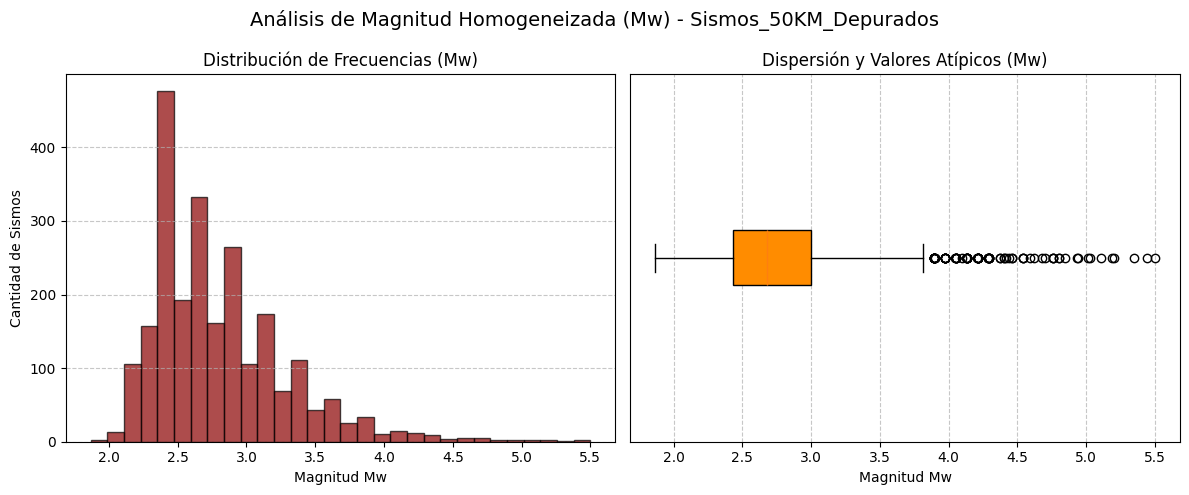


REPORTE PARA: Sismos_260KM_Depurados.csv
Filas iniciales: 68592
Filas tras eliminar sismos no convertidos: 68497 (Se eliminaron 95)
-> SISMOS CON Mw MAYOR A 3: 16160
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_260KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---
count    68497.000000
mean         2.670601
std          0.541070
min          1.219350
25%          2.271700
50%          2.595500
75%          2.919300
max          7.400000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_260KM_Depurados...


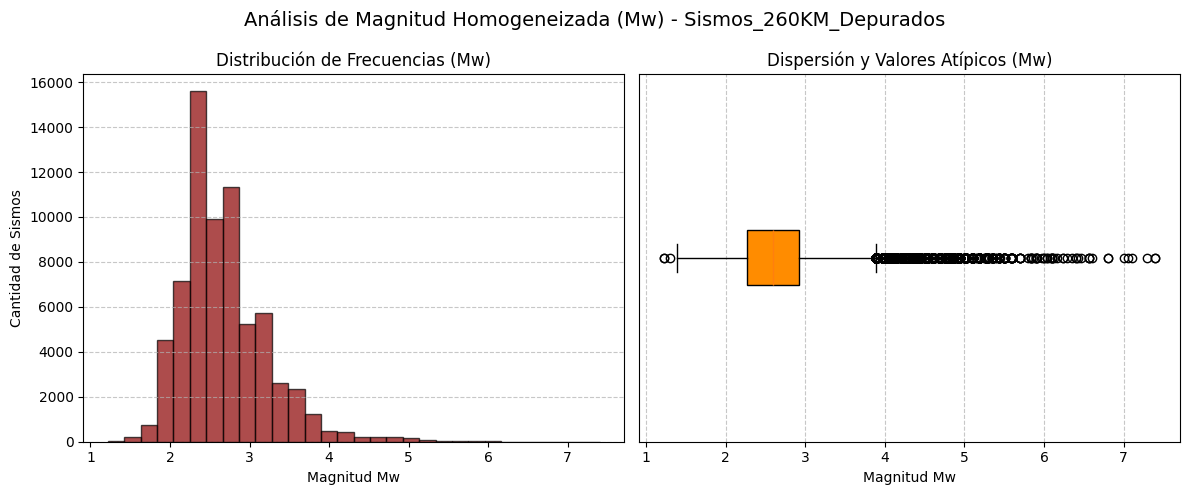

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Rutas de trabajo
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

# Archivos de entrada
archivos_entrada = [
    "Sismos_50KM_Depurados.csv",
    "Sismos_260KM_Depurados.csv"
]

def convertir_a_mw(magnitud, tipo_magnitud):
    try:
        valor = float(magnitud)
    except (TypeError, ValueError):
        return (pd.NA, "sin magnitud", pd.NA, "sin_magnitud")

    tipo = "" if pd.isna(tipo_magnitud) else str(tipo_magnitud).strip().lower()
    tipo_base = tipo.replace("_", "").replace("-", "")

    if tipo in {"mw", "mww", "mwc", "mwb", "mwr", "mwp"}:
        return (valor, "directa: " + str(tipo_magnitud), 0.0, "directa")
    if tipo in {"mw(mb)", "mwb(mb)"}:
        return (valor, "directa reportada: " + str(tipo_magnitud), 0.0, "directa")

    if tipo in {"mb", "mbasic"} or tipo_base == "mb":
        mw = 0.85 * valor + 1.02
        estado = "dentro_de_rango" if 3.5 <= valor <= 6.2 else "extrapolada"
        return (mw, "Scordilis: Mw=0.85 mb+1.02 (3.5<=mb<=6.2)", 0.29, estado)

    if tipo in {"ms", "msk"}:
        if valor <= 6.1:
            mw = 0.65 * valor + 2.20
            sigma = 0.17
            rango = "3.0<=Ms<=6.1"
        else:
            mw = 1.00 * valor - 0.02
            sigma = 0.21
            rango = "6.2<=Ms<=8.0"
        estado = "dentro_de_rango" if 3.0 <= valor <= 8.0 else "extrapolada"
        return (mw, f"Scordilis: {rango}", sigma, estado)

    es_local = (tipo in {"ml", "mlr", "mlv"} or tipo.startswith("mlr") or "mlr" in tipo)
    if es_local:
        mw = 0.8095 * valor + 1.3003
        estado = "dentro_de_rango" if 3.3 <= valor <= 6.6 else "extrapolada"
        return (mw, "Senel et al.: Mw=0.8095 ML+1.3003 (3.3<=ML<=6.6)", pd.NA, estado)

    if tipo in {"md", "mc"}:
        mw = 0.7947 * valor + 1.3420
        estado = "dentro_de_rango" if 3.5 <= valor <= 7.4 else "extrapolada"
        return (mw, "Senel et al.: Mw=0.7947 Md+1.3420 (3.5<=Md<=7.4)", pd.NA, estado)

    return (pd.NA, "sin correlacion verificable", pd.NA, "no_convertida")


def agregar_columnas_mw(df):
    conversiones = [
        convertir_a_mw(mag, tipo)
        for mag, tipo in zip(df["magnitud"], df["tipo_magnitud"])
    ]
    df[["escala_mw", "relacion_conversion", "sigma_conversion", "estado_conversion"]] = pd.DataFrame(conversiones, index=df.index)
    return df


for archivo in archivos_entrada:
    ruta_completa_entrada = os.path.join(DIRECTORIO_DEPURADOS, archivo)
    
    try:
        # Cargar el archivo previamente depurado
        df_depurado = pd.read_csv(ruta_completa_entrada)
        total_inicial = len(df_depurado)
        
        # Aplicar la conversión a Mw
        df_homogeneizado = agregar_columnas_mw(df_depurado)
        
        # ELIMINAR DATOS NO CONVERTIDOS
        # Elimina las filas donde 'escala_mw' es nulo
        df_homogeneizado = df_homogeneizado.dropna(subset=['escala_mw']).copy()
        
        # Asegurarnos de que la columna sea tratada como número para poder graficar/medir
        df_homogeneizado['escala_mw'] = df_homogeneizado['escala_mw'].astype(float)
        
        total_final = len(df_homogeneizado)
        sismos_eliminados = total_inicial - total_final
        
        # CONTAR DATOS MAYORES A 3
        sismos_mayores_a_3 = len(df_homogeneizado[df_homogeneizado['escala_mw'] > 3])
        
        # Guardar archivo
        nombre_base, extension = os.path.splitext(archivo)
        archivo_salida = f"{nombre_base}_mw{extension}"
        ruta_completa_salida = os.path.join(DIRECTORIO_DEPURADOS, archivo_salida)
        df_homogeneizado.to_csv(ruta_completa_salida, index=False, encoding="utf-8-sig")
        
        # --- REPORTE EN CONSOLA ---
        print(f"\n" + "="*65)
        print(f"REPORTE PARA: {archivo}")
        print("="*65)
        print(f"Filas iniciales: {total_inicial}")
        print(f"Filas tras eliminar sismos no convertidos: {total_final} (Se eliminaron {sismos_eliminados})")
        print(f"-> SISMOS CON Mw MAYOR A 3: {sismos_mayores_a_3}")
        print(f"-> Archivo guardado en: {ruta_completa_salida}")
        
        print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---")
        print(df_homogeneizado['escala_mw'].describe())
        
        # --- GRÁFICOS ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Análisis de Magnitud Homogeneizada (Mw) - {nombre_base}', fontsize=14)
        
        # Histograma
        axes[0].hist(df_homogeneizado['escala_mw'], bins=30, color='#8B0000', edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribución de Frecuencias (Mw)')
        axes[0].set_xlabel('Magnitud Mw')
        axes[0].set_ylabel('Cantidad de Sismos')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Diagrama de caja (Boxplot)
        axes[1].boxplot(df_homogeneizado['escala_mw'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#FF8C00', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos (Mw)')
        axes[1].set_xlabel('Magnitud Mw')
        axes[1].set_yticks([]) 
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        print(f"\nAbriendo ventana de gráficos para {nombre_base}...")
        plt.show()
        
    except FileNotFoundError:
        print(f"\n[ERROR] No se encontró el archivo: {ruta_completa_entrada}")
    except Exception as e:
        print(f"\n[ERROR] Ocurrió un problema con {archivo}: {e}")


REPORTE PARA: Sismos_50KM_Depurados.csv
Filas iniciales: 2400
Filas tras eliminar sismos no convertidos/extrapolados: 139 (Se eliminaron 2261)
-> SISMOS CON Mw MAYOR A 3: 110
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_50KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---
count    139.000000
mean       3.535868
std        0.629982
min        2.800000
25%        3.069800
50%        3.261400
75%        3.868100
max        5.500000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_50KM_Depurados...


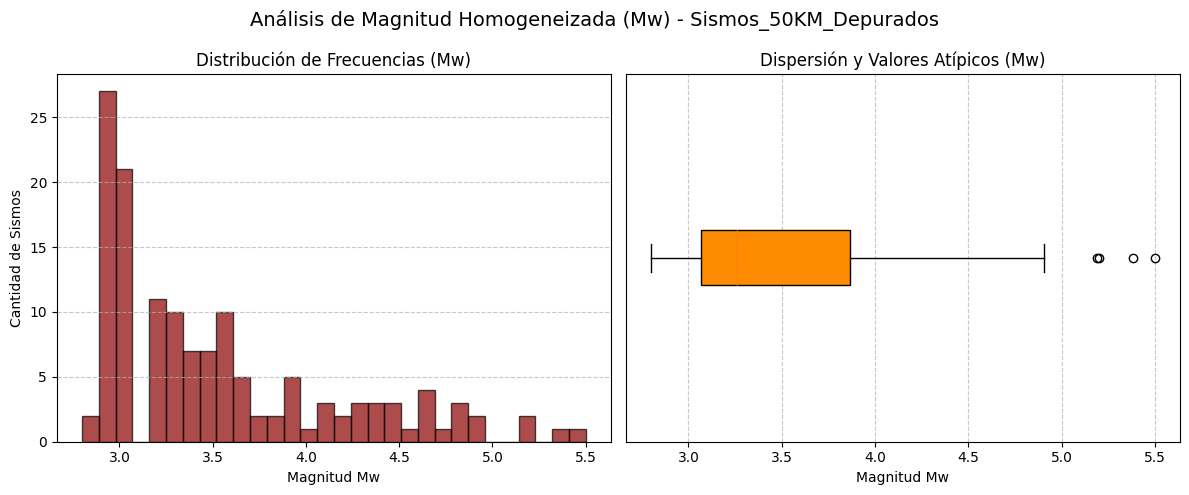


REPORTE PARA: Sismos_260KM_Depurados.csv
Filas iniciales: 68592
Filas tras eliminar sismos no convertidos/extrapolados: 3444 (Se eliminaron 65148)
-> SISMOS CON Mw MAYOR A 3: 2839
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_260KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---
count    3444.000000
mean        3.604974
std         0.705635
min         1.600000
25%         3.069800
50%         3.357200
75%         3.949800
max         7.400000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_260KM_Depurados...


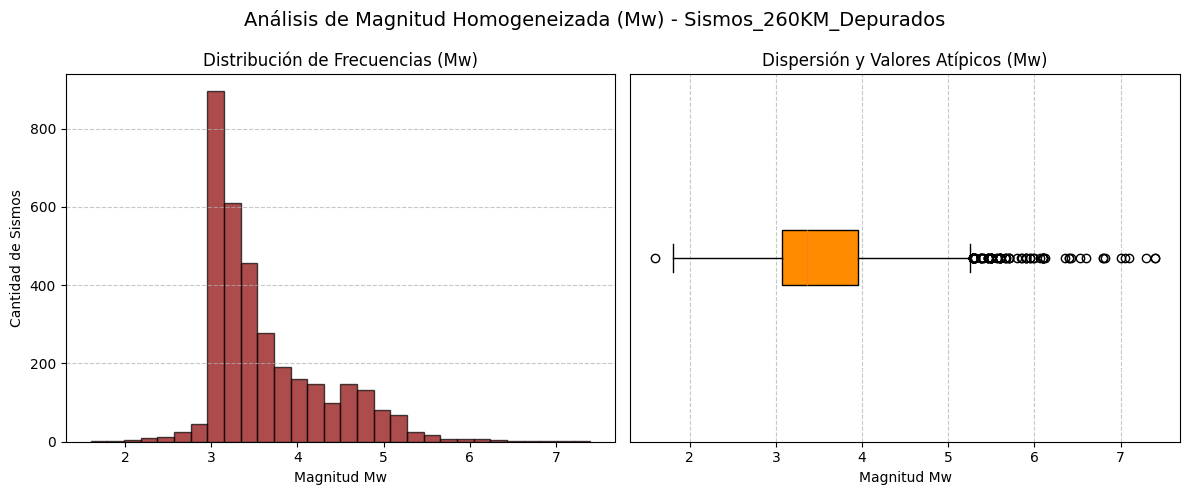

In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Rutas de trabajo
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

# Archivos de entrada
archivos_entrada = [
    "Sismos_50KM_Depurados.csv",
    "Sismos_260KM_Depurados.csv"
]

def convertir_a_mw(magnitud, tipo_magnitud):
    try:
        valor = float(magnitud)
    except (TypeError, ValueError):
        return (pd.NA, "sin magnitud", pd.NA, "sin_magnitud")

    tipo = "" if pd.isna(tipo_magnitud) else str(tipo_magnitud).strip().lower()
    tipo_base = tipo.replace("_", "").replace("-", "")

    # 1. Magnitudes reportadas directamente como Mw
    if tipo in {"mw", "mww", "mwc", "mwb", "mwr", "mwp"}:
        return (valor, "directa: " + str(tipo_magnitud), 0.0, "directa")
    if tipo in {"mw(mb)", "mwb(mb)"}:
        return (valor, "directa reportada: " + str(tipo_magnitud), 0.0, "directa")

    # 2. Conversión desde ondas de cuerpo (mb)
    if tipo in {"mb", "mbasic"} or tipo_base == "mb":
        if 3.6 < valor <= 5.7:
            mw = 0.954 * valor + 0.42
            return (mw, "Mw = 0.954 mb + 0.42", 0.28, "convertida")
        elif 5.7 < valor <= 7.7:
            mw = 1.433 * valor - 2.35
            return (mw, "Mw = 1.433 mb - 2.35", 0.36, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 3. Conversión desde ondas superficiales (Ms)
    if tipo in {"ms", "msk"}:
        if 3.6 < valor <= 6.1:
            mw = 0.689 * valor + 1.93
            return (mw, "Mw = 0.689 Ms + 1.93", 0.20, "convertida")
        elif 6.1 < valor <= 8.9:
            mw = 0.928 * valor + 0.474
            return (mw, "Mw = 0.928 Ms + 0.474", 0.18, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 4. Conversión desde magnitud local (ML)
    es_local = (tipo in {"ml", "mlr", "mlv"} or tipo.startswith("mlr") or "mlr" in tipo)
    if es_local:
        if 2.9 < valor <= 6.1:
            mw = 0.958 * valor + 0.1
            return (mw, "Mw = 0.958 ML + 0.1", 0.50, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 5. Conversión desde magnitud de duración (Md)
    if tipo in {"md", "mc"}:
        if 3.5 <= valor <= 7.4:
            mw = 0.7947 * valor + 1.3420
            return (mw, "Mw = 0.7947 Md + 1.3420", pd.NA, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    return (pd.NA, "sin correlacion verificable", pd.NA, "no_convertida")


def agregar_columnas_mw(df):
    conversiones = [
        convertir_a_mw(mag, tipo)
        for mag, tipo in zip(df["magnitud"], df["tipo_magnitud"])
    ]
    df[["escala_mw", "relacion_conversion", "sigma_conversion", "estado_conversion"]] = pd.DataFrame(conversiones, index=df.index)
    return df


for archivo in archivos_entrada:
    ruta_completa_entrada = os.path.join(DIRECTORIO_DEPURADOS, archivo)
    
    try:
        # Cargar el archivo previamente depurado
        df_depurado = pd.read_csv(ruta_completa_entrada)
        total_inicial = len(df_depurado)
        
        # Aplicar la conversión a Mw
        df_homogeneizado = agregar_columnas_mw(df_depurado)
        
        # ELIMINAR DATOS NO CONVERTIDOS Y EXTRAPOLADOS
        # Las filas donde 'escala_mw' es pd.NA (por extrapolación o falta de correlación) se eliminan aquí
        df_homogeneizado = df_homogeneizado.dropna(subset=['escala_mw']).copy()
        
        # Asegurarnos de que la columna sea tratada como número para poder graficar/medir
        df_homogeneizado['escala_mw'] = df_homogeneizado['escala_mw'].astype(float)
        
        total_final = len(df_homogeneizado)
        sismos_eliminados = total_inicial - total_final
        
        # CONTAR DATOS MAYORES A 3
        sismos_mayores_a_3 = len(df_homogeneizado[df_homogeneizado['escala_mw'] > 3])
        
        # Guardar archivo
        nombre_base, extension = os.path.splitext(archivo)
        archivo_salida = f"{nombre_base}_mw{extension}"
        ruta_completa_salida = os.path.join(DIRECTORIO_DEPURADOS, archivo_salida)
        df_homogeneizado.to_csv(ruta_completa_salida, index=False, encoding="utf-8-sig")
        
        # --- REPORTE EN CONSOLA ---
        print(f"\n" + "="*65)
        print(f"REPORTE PARA: {archivo}")
        print("="*65)
        print(f"Filas iniciales: {total_inicial}")
        print(f"Filas tras eliminar sismos no convertidos/extrapolados: {total_final} (Se eliminaron {sismos_eliminados})")
        print(f"-> SISMOS CON Mw MAYOR A 3: {sismos_mayores_a_3}")
        print(f"-> Archivo guardado en: {ruta_completa_salida}")
        
        print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw) ---")
        print(df_homogeneizado['escala_mw'].describe())
        
        # --- GRÁFICOS SOBRE LA INFORMACIÓN QUE QUEDA ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Análisis de Magnitud Homogeneizada (Mw) - {nombre_base}', fontsize=14)
        
        # Histograma
        axes[0].hist(df_homogeneizado['escala_mw'], bins=30, color='#8B0000', edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribución de Frecuencias (Mw)')
        axes[0].set_xlabel('Magnitud Mw')
        axes[0].set_ylabel('Cantidad de Sismos')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Diagrama de caja (Boxplot)
        axes[1].boxplot(df_homogeneizado['escala_mw'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#FF8C00', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos (Mw)')
        axes[1].set_xlabel('Magnitud Mw')
        axes[1].set_yticks([]) 
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        print(f"\nAbriendo ventana de gráficos para {nombre_base}...")
        plt.show()
        
    except FileNotFoundError:
        print(f"\n[ERROR] No se encontró el archivo: {ruta_completa_entrada}")
    except Exception as e:
        print(f"\n[ERROR] Ocurrió un problema con {archivo}: {e}")


REPORTE PARA: Sismos_50KM_Depurados.csv
Filas iniciales crudas: 2400
Sismos eliminados por extrapolación o Mw < 3: 2290
Réplicas eliminadas (10km, 24h): 0
-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: 110

--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---
count        110.000
mean           3.688
std            0.625
min            3.070
25%            3.166
50%            3.453
75%            4.118
max            5.500
var            0.390
asimetría      1.009
curtosis       0.072
Name: escala_mw, dtype: float64


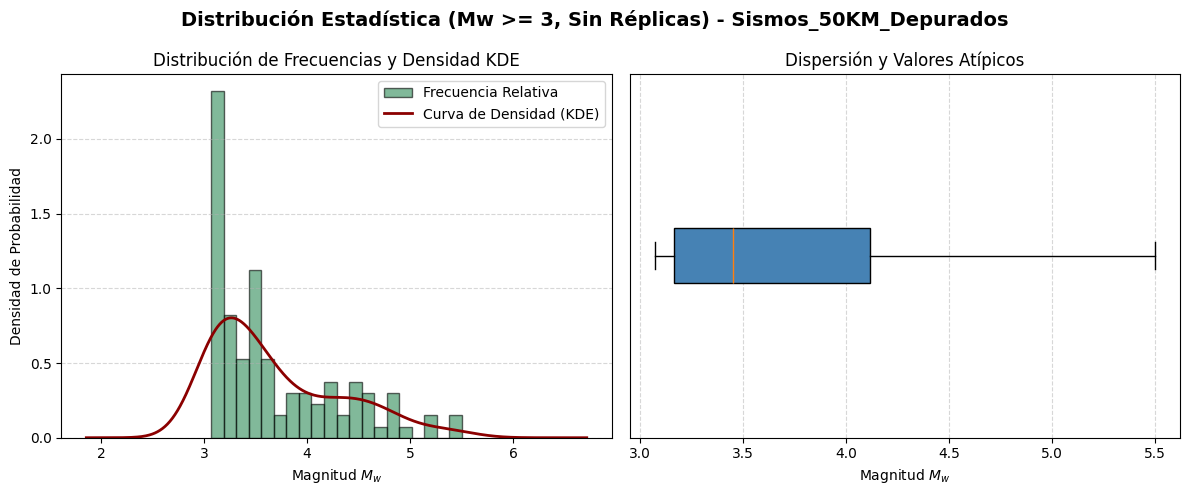


REPORTE PARA: Sismos_260KM_Depurados.csv
Filas iniciales crudas: 68592
Sismos eliminados por extrapolación o Mw < 3: 65718
Réplicas eliminadas (10km, 24h): 247
-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: 2627

--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---
count        2627.000
mean            3.765
std             0.706
min             3.000
25%             3.200
50%             3.500
75%             4.219
max             7.400
var             0.498
asimetría       1.273
curtosis        1.648
Name: escala_mw, dtype: float64


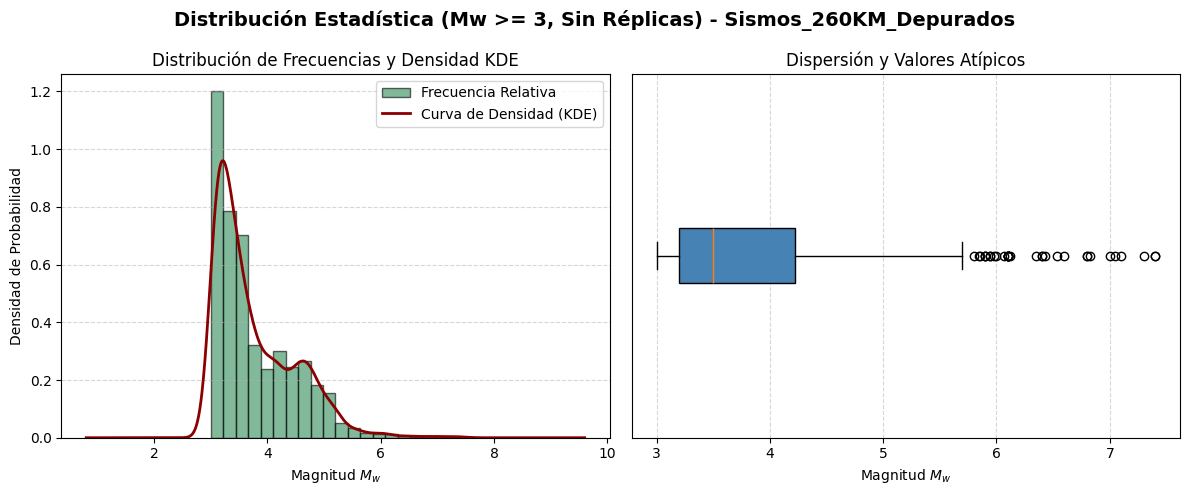

In [27]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Rutas de trabajo (Ajustar según tu entorno)
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

archivos_entrada = [
    "Sismos_50KM_Depurados.csv",
    "Sismos_260KM_Depurados.csv"
]

# Parámetros para la eliminación de réplicas
DISTANCIA_REPLICA_TAREA_KM = 10.0
TIEMPO_REPLICA_TAREA_HORAS = 24.0

def distancia_km(latitud_1, longitud_1, latitud_2, longitud_2):
    """Calcula la distancia de gran circulo con la formula de Haversine."""
    radio_tierra = 6371.0
    latitud_1 = np.radians(latitud_1)
    latitud_2 = np.radians(latitud_2)
    diferencia_latitud = latitud_2 - latitud_1
    diferencia_longitud = np.radians(longitud_2 - longitud_1)
    termino = (
        np.sin(diferencia_latitud / 2) ** 2
        + np.cos(latitud_1)
        * np.cos(latitud_2)
        * np.sin(diferencia_longitud / 2) ** 2
    )
    return 2 * radio_tierra * np.arcsin(np.sqrt(termino))

def convertir_a_mw(magnitud, tipo_magnitud):
    try:
        valor = float(magnitud)
    except (TypeError, ValueError):
        return (pd.NA, "sin magnitud", pd.NA, "sin_magnitud")

    tipo = "" if pd.isna(tipo_magnitud) else str(tipo_magnitud).strip().lower()
    tipo_base = tipo.replace("_", "").replace("-", "")

    if tipo in {"mw", "mww", "mwc", "mwb", "mwr", "mwp"}:
        return (valor, "directa: " + str(tipo_magnitud), 0.0, "directa")
    if tipo in {"mw(mb)", "mwb(mb)"}:
        return (valor, "directa reportada: " + str(tipo_magnitud), 0.0, "directa")

    if tipo in {"mb", "mbasic"} or tipo_base == "mb":
        if 3.6 < valor <= 5.7:
            return (0.954 * valor + 0.42, "Mw = 0.954 mb + 0.42", 0.28, "convertida")
        elif 5.7 < valor <= 7.7:
            return (1.433 * valor - 2.35, "Mw = 1.433 mb - 2.35", 0.36, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    if tipo in {"ms", "msk"}:
        if 3.6 < valor <= 6.1:
            return (0.689 * valor + 1.93, "Mw = 0.689 Ms + 1.93", 0.20, "convertida")
        elif 6.1 < valor <= 8.9:
            return (0.928 * valor + 0.474, "Mw = 0.928 Ms + 0.474", 0.18, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    es_local = (tipo in {"ml", "mlr", "mlv"} or tipo.startswith("mlr") or "mlr" in tipo)
    if es_local:
        if 2.9 < valor <= 6.1:
            return (0.958 * valor + 0.1, "Mw = 0.958 ML + 0.1", 0.50, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    if tipo in {"md", "mc"}:
        if 3.5 <= valor <= 7.4:
            return (0.7947 * valor + 1.3420, "Mw = 0.7947 Md + 1.3420", pd.NA, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    return (pd.NA, "sin correlacion verificable", pd.NA, "no_convertida")

def agregar_columnas_mw(df):
    conversiones = [
        convertir_a_mw(mag, tipo) for mag, tipo in zip(df["magnitud"], df["tipo_magnitud"])
    ]
    df[["escala_mw", "relacion_conversion", "sigma_conversion", "estado_conversion"]] = pd.DataFrame(conversiones, index=df.index)
    return df

def declusterizar_criterio_propio(df):
    """Elimina réplicas usando 24 horas y 10 km (Criterio del txt)."""
    resultado = df.copy()
    
    # --- ASIGNACIÓN ESTRICTA DE LA COLUMNA 'hora' ---
    col_fecha = "hora" 
    col_lat = "latitude" if "latitude" in resultado.columns else "latitud"
    col_lon = "longitude" if "longitude" in resultado.columns else "longitud"
    
    # pd.to_datetime maneja automáticamente el formato ISO 8601 con zona horaria
    resultado[col_fecha] = pd.to_datetime(resultado[col_fecha], utc=True, errors="coerce")
    
    for col in (col_lat, col_lon, "escala_mw"):
        resultado[col] = pd.to_numeric(resultado[col], errors="coerce")

    # Agrupación por día usando la columna 'hora' ya convertida
    resultado["_dia_propio"] = resultado[col_fecha].dt.floor("D")
    excluidos = set()
    
    grupos_por_dia = resultado.groupby("_dia_propio", sort=True).groups
    for indices_dia in grupos_por_dia.values():
        orden = resultado.loc[list(indices_dia)].sort_values(
            ["escala_mw"], ascending=[False], na_position="last"
        ).index.tolist()
        
        for indice_principal in orden:
            if indice_principal in excluidos:
                continue
                
            fecha = resultado.at[indice_principal, col_fecha]
            latitud = resultado.at[indice_principal, col_lat]
            longitud = resultado.at[indice_principal, col_lon]
            magnitud = resultado.at[indice_principal, "escala_mw"]
            
            if pd.isna(fecha) or pd.isna(latitud) or pd.isna(longitud) or pd.isna(magnitud):
                continue

            candidatos = [i for i in orden if i != indice_principal and i not in excluidos]
            if not candidatos:
                continue

            diferencias_horas = np.array([
                abs((resultado.at[i, col_fecha] - fecha).total_seconds()) / 3600.0 for i in candidatos
            ])
            candidatos = [
                i for i, dif in zip(candidatos, diferencias_horas)
                if dif <= TIEMPO_REPLICA_TAREA_HORAS and resultado.at[i, "escala_mw"] < magnitud
            ]
            if not candidatos:
                continue

            distancias = distancia_km(
                latitud, longitud,
                resultado.loc[candidatos, col_lat].to_numpy(),
                resultado.loc[candidatos, col_lon].to_numpy(),
            )
            
            for indice_candidato, distancia in zip(candidatos, distancias):
                if pd.isna(distancia) or distancia > DISTANCIA_REPLICA_TAREA_KM:
                    continue
                excluidos.add(indice_candidato)

    resultado = resultado.drop(columns="_dia_propio")
    return resultado.drop(index=sorted(excluidos)).reset_index(drop=True), len(excluidos)

for archivo in archivos_entrada:
    ruta_completa_entrada = os.path.join(DIRECTORIO_DEPURADOS, archivo)
    
    try:
        df_depurado = pd.read_csv(ruta_completa_entrada)
        total_inicial = len(df_depurado)
        
        # 1. Aplicar conversiones
        df_homogeneizado = agregar_columnas_mw(df_depurado)
        df_homogeneizado = df_homogeneizado.dropna(subset=['escala_mw']).copy()
        df_homogeneizado['escala_mw'] = df_homogeneizado['escala_mw'].astype(float)
        
        # 2. Filtrar Mw >= 3
        df_filtrado_mw = df_homogeneizado[df_homogeneizado['escala_mw'] >= 3.0].copy()
        
        # 3. Eliminar Réplicas
        df_final, num_replicas = declusterizar_criterio_propio(df_filtrado_mw)
        total_final = len(df_final)
        
        # Guardar archivo con la nomenclatura solicitada
        nombre_base, _ = os.path.splitext(archivo)
        archivo_salida = f"{nombre_base}_onlymw.csv"
        ruta_completa_salida = os.path.join(DIRECTORIO_DEPURADOS, archivo_salida)
        df_final.to_csv(ruta_completa_salida, index=False, encoding="utf-8-sig")
        
        # --- REPORTE EN CONSOLA Y ESTADÍSTICAS DETALLADAS ---
        print(f"\n" + "="*70)
        print(f"REPORTE PARA: {archivo}")
        print("="*70)
        print(f"Filas iniciales crudas: {total_inicial}")
        print(f"Sismos eliminados por extrapolación o Mw < 3: {total_inicial - len(df_filtrado_mw)}")
        print(f"Réplicas eliminadas (10km, 24h): {num_replicas}")
        print(f"-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: {total_final}")
        
        # Generar estadística descriptiva detallada
        stats = df_final['escala_mw'].describe().copy()
        stats['var'] = df_final['escala_mw'].var()
        stats['asimetría'] = df_final['escala_mw'].skew() 
        stats['curtosis'] = df_final['escala_mw'].kurt()  
        
        print("\n--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---")
        print(stats.round(3))
        
        # --- GRÁFICOS DE DISTRIBUCIÓN ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # CORRECCIÓN AQUÍ: Se reemplaza $\ge$ por >= para evitar el error ParseFatalException
        fig.suptitle(f'Distribución Estadística (Mw >= 3, Sin Réplicas) - {nombre_base}', fontsize=14, fontweight='bold')
        
        # Histograma superpuesto con estimación de densidad (KDE)
        ax0 = axes[0]
        ax0.hist(df_final['escala_mw'], bins=20, density=True, color='#2E8B57', edgecolor='black', alpha=0.6, label='Frecuencia Relativa')
        df_final['escala_mw'].plot.kde(ax=ax0, color='darkred', linewidth=2, label='Curva de Densidad (KDE)')
        ax0.set_title('Distribución de Frecuencias y Densidad KDE')
        ax0.set_xlabel('Magnitud $M_w$')
        ax0.set_ylabel('Densidad de Probabilidad')
        ax0.legend()
        ax0.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Diagrama de caja (Boxplot) para ver atípicos
        axes[1].boxplot(df_final['escala_mw'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#4682B4', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos')
        axes[1].set_xlabel('Magnitud $M_w$')
        axes[1].set_yticks([]) 
        axes[1].grid(axis='x', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"\n[ERROR] No se encontró el archivo: {ruta_completa_entrada}")
    except Exception as e:
        print(f"\n[ERROR] Ocurrió un problema con {archivo}: {e}")


REPORTE PARA: Sismos_50KM_Depurados.csv
Filas iniciales crudas: 2400
Sismos eliminados por extrapolación o Mw < 3: 2290
Réplicas eliminadas (10km, 24h): 0
-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: 110

--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---
count        110.000
mean           3.688
std            0.625
min            3.070
25%            3.166
50%            3.453
75%            4.118
max            5.500
var            0.390
asimetría      1.009
curtosis       0.072
Name: escala_mw, dtype: float64


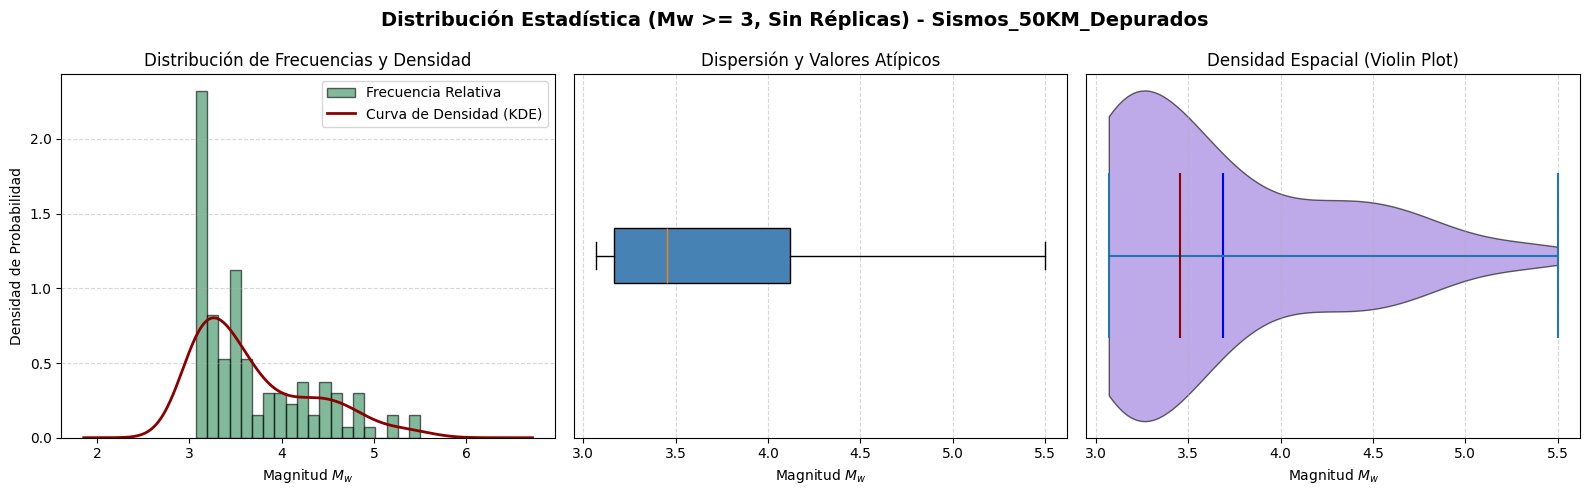


REPORTE PARA: Sismos_260KM_Depurados.csv
Filas iniciales crudas: 68592
Sismos eliminados por extrapolación o Mw < 3: 65718
Réplicas eliminadas (10km, 24h): 247
-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: 2627

--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---
count        2627.000
mean            3.765
std             0.706
min             3.000
25%             3.200
50%             3.500
75%             4.219
max             7.400
var             0.498
asimetría       1.273
curtosis        1.648
Name: escala_mw, dtype: float64


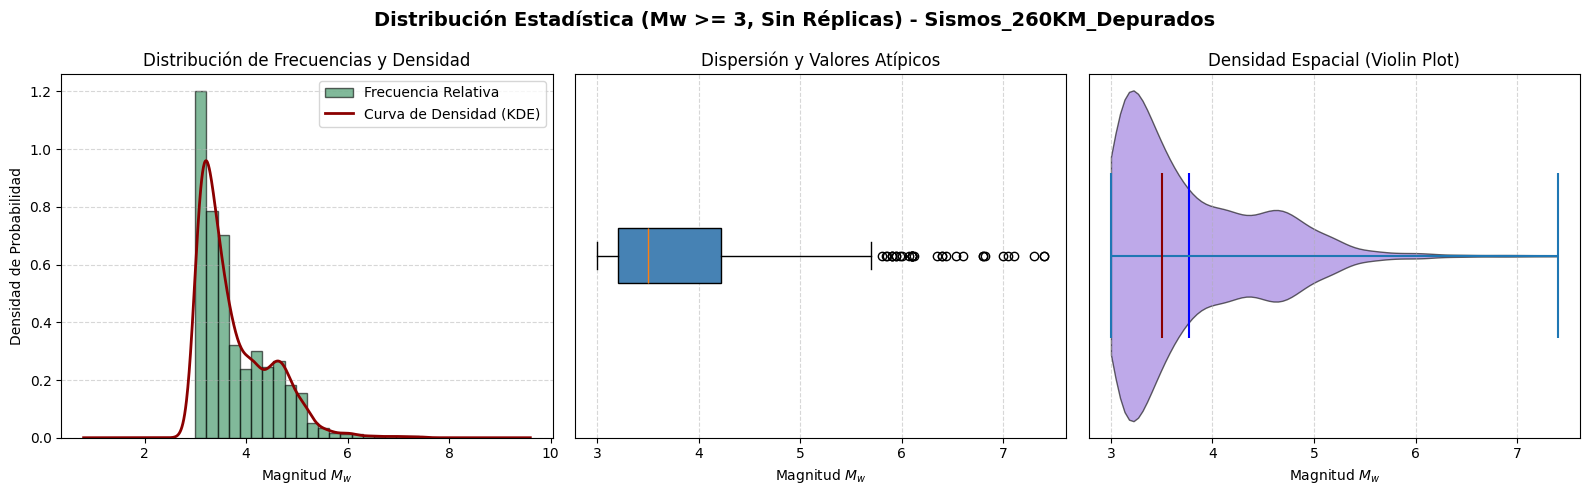

In [29]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Rutas de trabajo (Ajustar según tu entorno)
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

archivos_entrada = [
    "Sismos_50KM_Depurados.csv",
    "Sismos_260KM_Depurados.csv"
]

# Parámetros para la eliminación de réplicas
DISTANCIA_REPLICA_TAREA_KM = 10.0
TIEMPO_REPLICA_TAREA_HORAS = 24.0

def distancia_km(latitud_1, longitud_1, latitud_2, longitud_2):
    """Calcula la distancia de gran circulo con la formula de Haversine."""
    radio_tierra = 6371.0
    latitud_1 = np.radians(latitud_1)
    latitud_2 = np.radians(latitud_2)
    diferencia_latitud = latitud_2 - latitud_1
    diferencia_longitud = np.radians(longitud_2 - longitud_1)
    termino = (
        np.sin(diferencia_latitud / 2) ** 2
        + np.cos(latitud_1)
        * np.cos(latitud_2)
        * np.sin(diferencia_longitud / 2) ** 2
    )
    return 2 * radio_tierra * np.arcsin(np.sqrt(termino))

def convertir_a_mw(magnitud, tipo_magnitud):
    try:
        valor = float(magnitud)
    except (TypeError, ValueError):
        return (pd.NA, "sin magnitud", pd.NA, "sin_magnitud")

    tipo = "" if pd.isna(tipo_magnitud) else str(tipo_magnitud).strip().lower()
    tipo_base = tipo.replace("_", "").replace("-", "")

    if tipo in {"mw", "mww", "mwc", "mwb", "mwr", "mwp"}:
        return (valor, "directa: " + str(tipo_magnitud), 0.0, "directa")
    if tipo in {"mw(mb)", "mwb(mb)"}:
        return (valor, "directa reportada: " + str(tipo_magnitud), 0.0, "directa")

    if tipo in {"mb", "mbasic"} or tipo_base == "mb":
        if 3.6 < valor <= 5.7:
            return (0.954 * valor + 0.42, "Mw = 0.954 mb + 0.42", 0.28, "convertida")
        elif 5.7 < valor <= 7.7:
            return (1.433 * valor - 2.35, "Mw = 1.433 mb - 2.35", 0.36, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    if tipo in {"ms", "msk"}:
        if 3.6 < valor <= 6.1:
            return (0.689 * valor + 1.93, "Mw = 0.689 Ms + 1.93", 0.20, "convertida")
        elif 6.1 < valor <= 8.9:
            return (0.928 * valor + 0.474, "Mw = 0.928 Ms + 0.474", 0.18, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    es_local = (tipo in {"ml", "mlr", "mlv"} or tipo.startswith("mlr") or "mlr" in tipo)
    if es_local:
        if 2.9 < valor <= 6.1:
            return (0.958 * valor + 0.1, "Mw = 0.958 ML + 0.1", 0.50, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    if tipo in {"md", "mc"}:
        if 3.5 <= valor <= 7.4:
            return (0.7947 * valor + 1.3420, "Mw = 0.7947 Md + 1.3420", pd.NA, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    return (pd.NA, "sin correlacion verificable", pd.NA, "no_convertida")

def agregar_columnas_mw(df):
    conversiones = [
        convertir_a_mw(mag, tipo) for mag, tipo in zip(df["magnitud"], df["tipo_magnitud"])
    ]
    df[["escala_mw", "relacion_conversion", "sigma_conversion", "estado_conversion"]] = pd.DataFrame(conversiones, index=df.index)
    return df

def declusterizar_criterio_propio(df):
    """Elimina réplicas usando 24 horas y 10 km (Criterio del txt)."""
    resultado = df.copy()
    
    col_fecha = "hora" 
    col_lat = "latitude" if "latitude" in resultado.columns else "latitud"
    col_lon = "longitude" if "longitude" in resultado.columns else "longitud"
    
    resultado[col_fecha] = pd.to_datetime(resultado[col_fecha], utc=True, errors="coerce")
    
    for col in (col_lat, col_lon, "escala_mw"):
        resultado[col] = pd.to_numeric(resultado[col], errors="coerce")

    resultado["_dia_propio"] = resultado[col_fecha].dt.floor("D")
    excluidos = set()
    
    grupos_por_dia = resultado.groupby("_dia_propio", sort=True).groups
    for indices_dia in grupos_por_dia.values():
        orden = resultado.loc[list(indices_dia)].sort_values(
            ["escala_mw"], ascending=[False], na_position="last"
        ).index.tolist()
        
        for indice_principal in orden:
            if indice_principal in excluidos:
                continue
                
            fecha = resultado.at[indice_principal, col_fecha]
            latitud = resultado.at[indice_principal, col_lat]
            longitud = resultado.at[indice_principal, col_lon]
            magnitud = resultado.at[indice_principal, "escala_mw"]
            
            if pd.isna(fecha) or pd.isna(latitud) or pd.isna(longitud) or pd.isna(magnitud):
                continue

            candidatos = [i for i in orden if i != indice_principal and i not in excluidos]
            if not candidatos:
                continue

            diferencias_horas = np.array([
                abs((resultado.at[i, col_fecha] - fecha).total_seconds()) / 3600.0 for i in candidatos
            ])
            candidatos = [
                i for i, dif in zip(candidatos, diferencias_horas)
                if dif <= TIEMPO_REPLICA_TAREA_HORAS and resultado.at[i, "escala_mw"] < magnitud
            ]
            if not candidatos:
                continue

            distancias = distancia_km(
                latitud, longitud,
                resultado.loc[candidatos, col_lat].to_numpy(),
                resultado.loc[candidatos, col_lon].to_numpy(),
            )
            
            for indice_candidato, distancia in zip(candidatos, distancias):
                if pd.isna(distancia) or distancia > DISTANCIA_REPLICA_TAREA_KM:
                    continue
                excluidos.add(indice_candidato)

    resultado = resultado.drop(columns="_dia_propio")
    return resultado.drop(index=sorted(excluidos)).reset_index(drop=True), len(excluidos)

for archivo in archivos_entrada:
    ruta_completa_entrada = os.path.join(DIRECTORIO_DEPURADOS, archivo)
    
    try:
        df_depurado = pd.read_csv(ruta_completa_entrada)
        total_inicial = len(df_depurado)
        
        # 1. Aplicar conversiones
        df_homogeneizado = agregar_columnas_mw(df_depurado)
        df_homogeneizado = df_homogeneizado.dropna(subset=['escala_mw']).copy()
        df_homogeneizado['escala_mw'] = df_homogeneizado['escala_mw'].astype(float)
        
        # 2. Filtrar Mw >= 3
        df_filtrado_mw = df_homogeneizado[df_homogeneizado['escala_mw'] >= 3.0].copy()
        
        # 3. Eliminar Réplicas
        df_final, num_replicas = declusterizar_criterio_propio(df_filtrado_mw)
        total_final = len(df_final)
        
        # Guardar archivo con la nomenclatura solicitada
        nombre_base, _ = os.path.splitext(archivo)
        archivo_salida = f"{nombre_base}_onlymw.csv"
        ruta_completa_salida = os.path.join(DIRECTORIO_DEPURADOS, archivo_salida)
        df_final.to_csv(ruta_completa_salida, index=False, encoding="utf-8-sig")
        
        # --- REPORTE EN CONSOLA Y ESTADÍSTICAS DETALLADAS ---
        print(f"\n" + "="*70)
        print(f"REPORTE PARA: {archivo}")
        print("="*70)
        print(f"Filas iniciales crudas: {total_inicial}")
        print(f"Sismos eliminados por extrapolación o Mw < 3: {total_inicial - len(df_filtrado_mw)}")
        print(f"Réplicas eliminadas (10km, 24h): {num_replicas}")
        print(f"-> TOTAL SISMOS PRINCIPALES CON Mw >= 3: {total_final}")
        
        stats = df_final['escala_mw'].describe().copy()
        stats['var'] = df_final['escala_mw'].var()
        stats['asimetría'] = df_final['escala_mw'].skew() 
        stats['curtosis'] = df_final['escala_mw'].kurt()  
        
        print("\n--- ESTADÍSTICA DESCRIPTIVA DETALLADA (Mw) ---")
        print(stats.round(3))
        
        # --- GRÁFICOS DE DISTRIBUCIÓN (AHORA CON VIOLIN PLOT) ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Distribución Estadística (Mw >= 3, Sin Réplicas) - {nombre_base}', fontsize=14, fontweight='bold')
        
        # 1. Histograma superpuesto con estimación de densidad (KDE)
        ax0 = axes[0]
        ax0.hist(df_final['escala_mw'], bins=20, density=True, color='#2E8B57', edgecolor='black', alpha=0.6, label='Frecuencia Relativa')
        df_final['escala_mw'].plot.kde(ax=ax0, color='darkred', linewidth=2, label='Curva de Densidad (KDE)')
        ax0.set_title('Distribución de Frecuencias y Densidad')
        ax0.set_xlabel('Magnitud $M_w$')
        ax0.set_ylabel('Densidad de Probabilidad')
        ax0.legend()
        ax0.grid(axis='y', linestyle='--', alpha=0.5)
        
        # 2. Diagrama de caja (Boxplot)
        ax1 = axes[1]
        ax1.boxplot(df_final['escala_mw'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#4682B4', color='black'))
        ax1.set_title('Dispersión y Valores Atípicos')
        ax1.set_xlabel('Magnitud $M_w$')
        ax1.set_yticks([]) 
        ax1.grid(axis='x', linestyle='--', alpha=0.5)
        
        # 3. Diagrama de Violín
        ax2 = axes[2]
        violin_parts = ax2.violinplot(df_final['escala_mw'], vert=False, showmeans=True, showmedians=True)
        
        # Personalizar el color del violín
        for pc in violin_parts['bodies']:
            pc.set_facecolor('#9370DB') # Color púrpura suave
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
            
        violin_parts['cmeans'].set_color('blue')      # Media en azul
        violin_parts['cmedians'].set_color('darkred') # Mediana en rojo
        
        ax2.set_title('Densidad Espacial (Violin Plot)')
        ax2.set_xlabel('Magnitud $M_w$')
        ax2.set_yticks([])
        ax2.grid(axis='x', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"\n[ERROR] No se encontró el archivo: {ruta_completa_entrada}")
    except Exception as e:
        print(f"\n[ERROR] Ocurrió un problema con {archivo}: {e}")